# Assignment 2 - Convolution (Cats vs. Dogs)

## What this notebook does
- Builds **CNN models from scratch**
- Builds **pretrained transfer-learning models**
- Uses the assignment sample-size rules:
  - **Q1:** training sample = **1000 total = 500 cats + 500 dogs**
  - **Q2:** increase training size while keeping validation and test the same
  - **Q3:** try multiple training sizes to find the best-performing size
  - **Q4:** repeat Q1-Q3 using a **pretrained network**



## 1. Runtime setup
In Colab:
1. Click **Runtime > Change runtime type**
2. Set **Hardware accelerator = GPU**
3. Run the cells below

In [1]:
# Colab / Python setup
import os
import shutil
import random
import pathlib
import json
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))
SEED = 42
keras.utils.set_random_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Mount Google Drive in Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Point this notebook to the dataset

### Expected folder structure
This notebook expects a dataset directory like this:

```text
your_dataset_folder/
    train/
        cats/
        dogs/
    validation/
        cats/
        dogs/
    test/
        cats/
        dogs/
```


In [3]:
BASE_DIR = Path("/content/drive/MyDrive/Colab Notebooks/cats_vs_dogs_small")

assert BASE_DIR.exists(), f"Dataset folder not found: {BASE_DIR}"
print("Using dataset folder:", BASE_DIR)

for split in ["train", "validation", "test"]:
    for label in ["cats", "dogs"]:
        p = BASE_DIR / split / label
        print(split, label, "->", len(list(p.glob("*"))))

Using dataset folder: /content/drive/MyDrive/Colab Notebooks/cats_vs_dogs_small
train cats -> 1000
train dogs -> 1000
validation cats -> 500
validation dogs -> 500
test cats -> 500
test dogs -> 500


## 3. Assignment sample-size helpers

This section:
- randomly samples exactly the number of cat and dog images needed
- creates a clean working subset for each experiment
- guarantees repeatable experiments using a fixed random seed

In [4]:
WORK_ROOT = Path("/content/assignment2_work")
WORK_ROOT.mkdir(parents=True, exist_ok=True)

def list_images(folder):
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".gif"}
    files = [p for p in folder.iterdir() if p.suffix.lower() in exts]
    files.sort()
    return files

def sample_class_files(source_dir, n, seed=42):
    files = list_images(source_dir)
    if n > len(files):
        raise ValueError(f"Requested {n} files from {source_dir}, but only found {len(files)}")
    rng = random.Random(seed)
    sampled = files[:]
    rng.shuffle(sampled)
    return sampled[:n]

def clear_dir(path):
    if path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)

def build_subset_dataset(exp_name, train_per_class, val_per_class=250, test_per_class=250, seed=42):
    exp_dir = WORK_ROOT / exp_name
    clear_dir(exp_dir)

    split_plan = {
        "train": train_per_class,
        "validation": val_per_class,
        "test": test_per_class,
    }

    for split, n_per_class in split_plan.items():
        for label in ["cats", "dogs"]:
            src = BASE_DIR / split / label
            dst = exp_dir / split / label
            dst.mkdir(parents=True, exist_ok=True)
            chosen = sample_class_files(src, n_per_class, seed=seed + hash((exp_name, split, label)) % 10000)
            for f in chosen:
                shutil.copy2(f, dst / f.name)

    return exp_dir

def make_datasets(exp_dir, image_size=(180, 180), batch_size=32):
    train_ds = keras.utils.image_dataset_from_directory(
        exp_dir / "train",
        labels="inferred",
        label_mode="binary",
        image_size=image_size,
        batch_size=batch_size,
        shuffle=True,
        seed=SEED
    )
    val_ds = keras.utils.image_dataset_from_directory(
        exp_dir / "validation",
        labels="inferred",
        label_mode="binary",
        image_size=image_size,
        batch_size=batch_size,
        shuffle=False
    )
    test_ds = keras.utils.image_dataset_from_directory(
        exp_dir / "test",
        labels="inferred",
        label_mode="binary",
        image_size=image_size,
        batch_size=batch_size,
        shuffle=False
    )

    AUTOTUNE = tf.data.AUTOTUNE
    train_ds = train_ds.prefetch(AUTOTUNE)
    val_ds = val_ds.prefetch(AUTOTUNE)
    test_ds = test_ds.prefetch(AUTOTUNE)
    return train_ds, val_ds, test_ds

## 4. Quick sample-size check


In [5]:
demo_dir = build_subset_dataset("check_q1", train_per_class=500, val_per_class=250, test_per_class=250, seed=SEED)

for split in ["train", "validation", "test"]:
    for label in ["cats", "dogs"]:
        count = len(list((demo_dir / split / label).glob("*")))
        print(f"{split:10s} {label:5s}: {count}")

train      cats : 500
train      dogs : 500
validation cats : 250
validation dogs : 250
test       cats : 250
test       dogs : 250


## 5. Model 1 - CNN trained from scratch
This model includes:
- rescaling
- data augmentation
- dropout
- batch normalization
- early stopping
- learning-rate reduction

These are good choices for the assignment because they help reduce overfitting.

In [6]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.10),
    ],
    name="data_augmentation"
)

def build_scratch_model(image_size=(180, 180)):
    inputs = keras.Input(shape=image_size + (3,))
    x = layers.Rescaling(1.0 / 255)(inputs)
    x = data_augmentation(x)

    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(256, 3, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Flatten()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs, name="scratch_cnn")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

scratch_model = build_scratch_model()
scratch_model.summary()

Model: "scratch_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 180, 180, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 90, 90, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 45, 45, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 22, 22, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 22, 22, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 11, 11, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     7,930,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,320,705 (31.74 MB)

 Trainable params: 8,319,745 (31.74 MB)

 Non-trainable params: 960 (3.75 KB)

In [7]:
def train_and_evaluate(model, train_ds, val_ds, test_ds, epochs=20, model_name="model"):
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=4,
            mode="max",
            restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6
        )
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1
    )

    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    val_loss, val_acc = model.evaluate(val_ds, verbose=0)

    result = {
        "model_name": model_name,
        "best_val_accuracy": float(np.max(history.history["val_accuracy"])),
        "final_val_accuracy": float(val_acc),
        "test_accuracy": float(test_acc),
        "test_loss": float(test_loss),
        "epochs_ran": len(history.history["loss"])
    }
    return history, result

def plot_history(history, title):
    hist = pd.DataFrame(history.history)
    plt.figure(figsize=(8, 5))
    plt.plot(hist.index + 1, hist["accuracy"], label="Train Accuracy")
    plt.plot(hist.index + 1, hist["val_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 6. Q1 - From scratch with 1000 training images total
Assignment requirement:
- Train = **500 cats + 500 dogs**
- Validation = **250 cats + 250 dogs**
- Test = **250 cats + 250 dogs**

Found 1000 files belonging to 2 classes.
Found 500 files belonging to 2 classes.
Found 500 files belonging to 2 classes.
Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 139ms/step - accuracy: 0.5810 - loss: 2.6297 - val_accuracy: 0.4920 - val_loss: 2.7179 - learning_rate: 0.0010
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - accuracy: 0.6110 - loss: 0.8024 - val_accuracy: 0.5020 - val_loss: 1.6499 - learning_rate: 0.0010
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - accuracy: 0.6150 - loss: 0.6747 - val_accuracy: 0.5000 - val_loss: 1.5023 - learning_rate: 0.0010
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 127ms/step - accuracy: 0.6690 - loss: 0.6224 - val_accuracy: 0.5000 - val_loss: 3.3004 - learning_rate: 0.0010
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 119ms/step - accuracy: 0.6890 - loss: 0.6127 - val_accuracy: 0.5000 - val_loss: 1.5074 - learning_rate: 0.0010
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - accuracy: 0.6940 - loss: 0.6156 - val_accuracy: 0.5040 - val_los

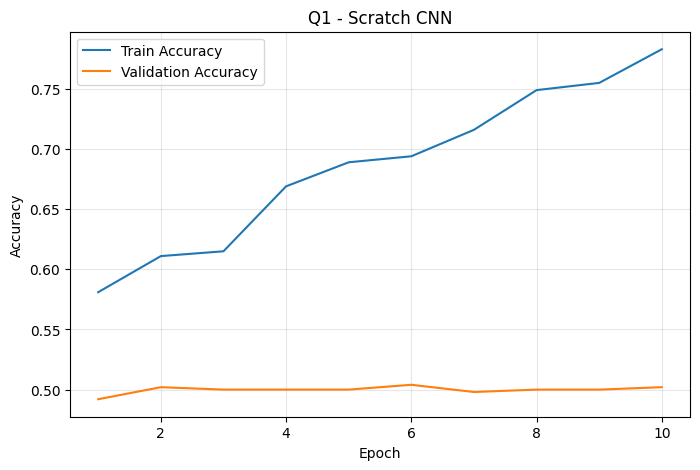

{'model_name': 'Scratch_Q1_1000total',
 'best_val_accuracy': 0.5040000081062317,
 'final_val_accuracy': 0.5040000081062317,
 'test_accuracy': 0.5040000081062317,
 'test_loss': 1.1370031833648682,
 'epochs_ran': 10}

In [8]:
q1_dir = build_subset_dataset("q1_scratch", train_per_class=500, val_per_class=250, test_per_class=250, seed=SEED)
q1_train_ds, q1_val_ds, q1_test_ds = make_datasets(q1_dir, image_size=(180, 180), batch_size=32)

q1_model = build_scratch_model()
q1_history, q1_result = train_and_evaluate(
    q1_model, q1_train_ds, q1_val_ds, q1_test_ds,
    epochs=20,
    model_name="Scratch_Q1_1000total"
)

plot_history(q1_history, "Q1 - Scratch CNN")
q1_result

## 7. Q2 - Increase the training sample size


Found 1400 files belonging to 2 classes.
Found 500 files belonging to 2 classes.
Found 500 files belonging to 2 classes.
Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 9s 125ms/step - accuracy: 0.5743 - loss: 2.5673 - val_accuracy: 0.5060 - val_loss: 1.9797 - learning_rate: 0.0010
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 9s 101ms/step - accuracy: 0.6100 - loss: 0.7405 - val_accuracy: 0.5000 - val_loss: 2.4499 - learning_rate: 0.0010
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 111ms/step - accuracy: 0.6043 - loss: 0.6590 - val_accuracy: 0.5200 - val_loss: 0.7250 - learning_rate: 0.0010
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - accuracy: 0.6686 - loss: 0.6182 - val_accuracy: 0.6020 - val_loss: 0.7397 - learning_rate: 0.0010
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - accuracy: 0.6779 - loss: 0.6362 - val_accuracy: 0.5560 - val_loss: 0.6935 - learning_rate: 0.0010
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - accuracy: 0.6993 - loss: 0.5868 - val_accuracy: 0.5000 - val_loss

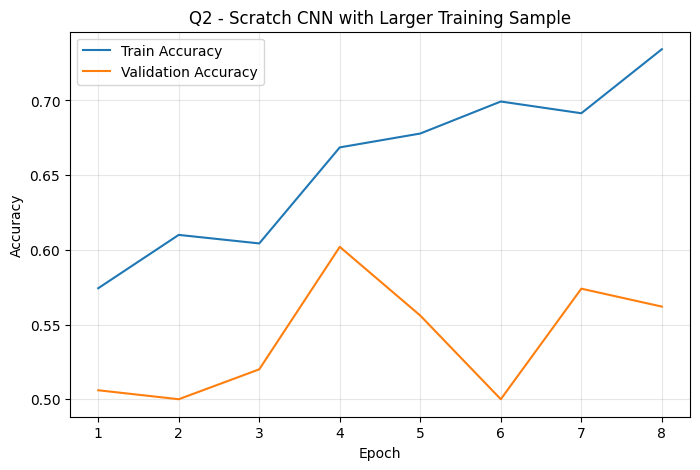

{'model_name': 'Scratch_Q2_1400total',
 'best_val_accuracy': 0.6019999980926514,
 'final_val_accuracy': 0.6019999980926514,
 'test_accuracy': 0.6060000061988831,
 'test_loss': 0.772143542766571,
 'epochs_ran': 8}

In [9]:
Q2_TRAIN_PER_CLASS = 700   # 700 cats + 700 dogs = 1400 total

q2_dir = build_subset_dataset("q2_scratch", train_per_class=Q2_TRAIN_PER_CLASS, val_per_class=250, test_per_class=250, seed=SEED)
q2_train_ds, q2_val_ds, q2_test_ds = make_datasets(q2_dir, image_size=(180, 180), batch_size=32)

q2_model = build_scratch_model()
q2_history, q2_result = train_and_evaluate(
    q2_model, q2_train_ds, q2_val_ds, q2_test_ds,
    epochs=20,
    model_name=f"Scratch_Q2_{Q2_TRAIN_PER_CLASS*2}total"
)

plot_history(q2_history, "Q2 - Scratch CNN with Larger Training Sample")
q2_result

## 8. Q3 - Find the best training size for the scratch model
This cell tests several training sizes and identifies the best one automatically.

Suggested list:
- 400 per class = 800 total
- 500 per class = 1000 total
- 700 per class = 1400 total
- 900 per class = 1800 total

In [10]:
scratch_sizes = [400, 500, 700, 900]   # per class
scratch_results = []

for per_class in scratch_sizes:
    exp_name = f"scratch_search_{per_class}"
    exp_dir = build_subset_dataset(exp_name, train_per_class=per_class, val_per_class=250, test_per_class=250, seed=SEED)
    train_ds, val_ds, test_ds = make_datasets(exp_dir, image_size=(180, 180), batch_size=32)

    model = build_scratch_model()
    history, result = train_and_evaluate(
        model, train_ds, val_ds, test_ds,
        epochs=15,
        model_name=f"Scratch_Search_{per_class*2}total"
    )
    result["train_per_class"] = per_class
    result["train_total"] = per_class * 2
    scratch_results.append(result)

scratch_df = pd.DataFrame(scratch_results).sort_values("test_accuracy", ascending=False).reset_index(drop=True)
scratch_df

Found 800 files belonging to 2 classes.
Found 500 files belonging to 2 classes.
Found 500 files belonging to 2 classes.
Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 133ms/step - accuracy: 0.5713 - loss: 2.8634 - val_accuracy: 0.5400 - val_loss: 0.9973 - learning_rate: 0.0010
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - accuracy: 0.6187 - loss: 0.8789 - val_accuracy: 0.5020 - val_loss: 1.1063 - learning_rate: 0.0010
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 145ms/step - accuracy: 0.6562 - loss: 0.6592 - val_accuracy: 0.5940 - val_loss: 0.6673 - learning_rate: 0.0010
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 122ms/step - accuracy: 0.7000 - loss: 0.5776 - val_accuracy: 0.5400 - val_loss: 0.7230 - learning_rate: 0.0010
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - accuracy: 0.7425 - loss: 0.5260 - val_accuracy: 0.5580 - val_loss: 0.6989 - learning_rate: 0.0010
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - accuracy: 0.7437 - loss: 0.4989 - val_accuracy: 0.5000 - val_loss:

,model_name,best_val_accuracy,final_val_accuracy,test_accuracy,test_loss,epochs_ran,train_per_class,train_total
0,Scratch_Search_1800total,0.538,0.538,0.556,0.777273,5,900,1800
1,Scratch_Search_1400total,0.532,0.532,0.550,0.835184,5,700,1400
2,Scratch_Search_800total,0.594,0.594,0.532,0.701970,7,400,800
3,Scratch_Search_1000total,0.538,0.538,0.526,0.735266,10,500,1000


In [11]:
best_scratch = scratch_df.iloc[0].to_dict()
best_scratch

{'model_name': 'Scratch_Search_1800total',
 'best_val_accuracy': 0.5379999876022339,
 'final_val_accuracy': 0.5379999876022339,
 'test_accuracy': 0.5559999942779541,
 'test_loss': 0.7772731781005859,
 'epochs_ran': 5,
 'train_per_class': 900,
 'train_total': 1800}

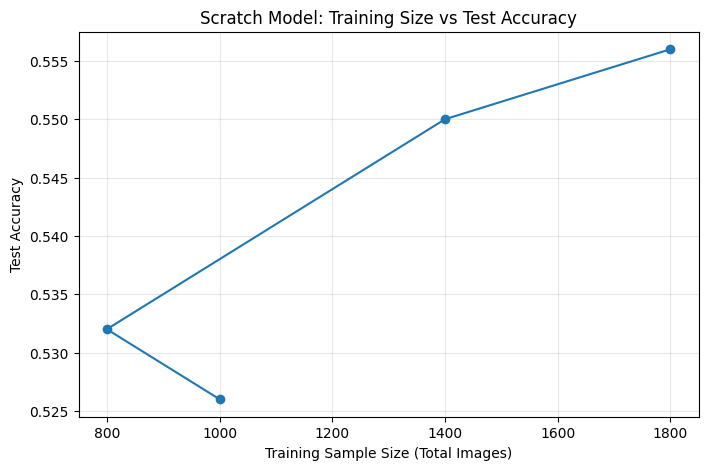

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(scratch_df["train_total"], scratch_df["test_accuracy"], marker="o")
plt.xlabel("Training Sample Size (Total Images)")
plt.ylabel("Test Accuracy")
plt.title("Scratch Model: Training Size vs Test Accuracy")
plt.grid(True, alpha=0.3)
plt.show()

## 9. Model 2 - Pretrained network (transfer learning)

This section uses **MobileNetV2** because it trains faster in Colab than some heavier models while still giving strong transfer-learning performance.

It has two stages:
1. **Feature extraction** with frozen pretrained weights
2. **Fine-tuning** the top layers

In [13]:
IMG_SIZE = (180, 180)

pretrained_data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.10),
    ],
    name="pretrained_data_aug"
)

def build_pretrained_model(image_size=IMG_SIZE, trainable_base=False):
    inputs = keras.Input(shape=image_size + (3,))
    x = pretrained_data_augmentation(inputs)
    x = keras.applications.mobilenet_v2.preprocess_input(x)

    base_model = keras.applications.MobileNetV2(
        input_shape=image_size + (3,),
        include_top=False,
        weights="imagenet"
    )
    base_model.trainable = trainable_base

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs, name="mobilenetv2_transfer")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model, base_model

def fine_tune_pretrained_model(model, base_model, unfreeze_last_n=30, learning_rate=1e-5):
    base_model.trainable = True
    for layer in base_model.layers[:-unfreeze_last_n]:
        layer.trainable = False

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

## 10. Q4A - Pretrained model with the same Q1 size
Start with:
- Train = **500 cats + 500 dogs**
- Validation = **250 cats + 250 dogs**
- Test = **250 cats + 250 dogs**

Found 1000 files belonging to 2 classes.
Found 500 files belonging to 2 classes.
Found 500 files belonging to 2 classes.


/tmp/ipykernel_3108/2657053214.py:17: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 127ms/step - accuracy: 0.5190 - loss: 0.8114 - val_accuracy: 0.6860 - val_loss: 0.5898 - learning_rate: 1.0000e-04
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.6650 - loss: 0.6323 - val_accuracy: 0.8460 - val_loss: 0.4573 - learning_rate: 1.0000e-04
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.7760 - loss: 0.4938 - val_accuracy: 0.9100 - val_loss: 0.3700 - learning_rate: 1.0000e-04
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - accuracy: 0.8150 - loss: 0.4283 - val_accuracy: 0.9340 - val_loss: 0.3049 - learning_rate: 1.0000e-04
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.8540 - loss: 0.3825 - val_accuracy: 0.9420 - val_loss: 0.2599 - learning_rate: 1.0000e-04
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.8840 - loss: 0.3292 - val_accuracy: 0.9580 - val_loss: 0.2260 - learning_rate: 1.0000e-04
Epoch 7/10
32/32 ━━

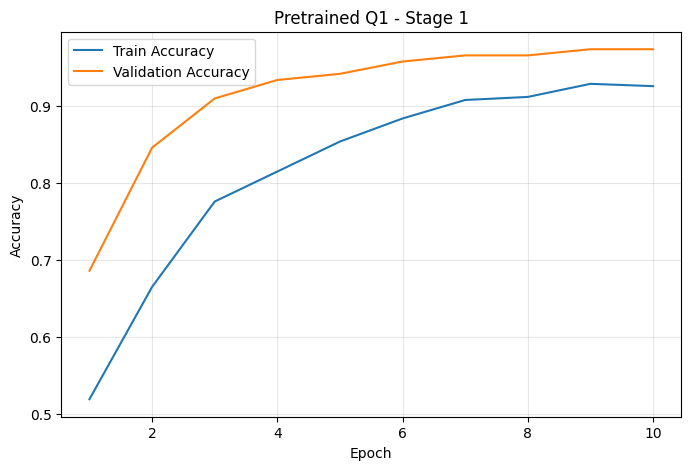

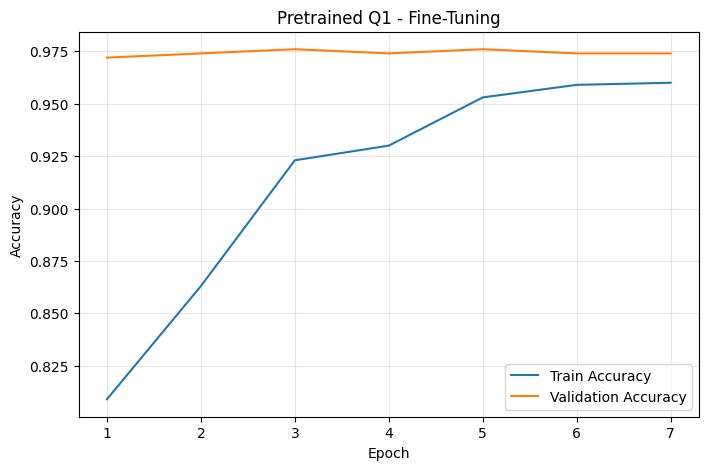

{'model_name': 'Pretrained_Q1_finetuned',
 'best_val_accuracy': 0.9760000109672546,
 'final_val_accuracy': 0.9760000109672546,
 'test_accuracy': 0.9819999933242798,
 'test_loss': 0.08585313707590103,
 'epochs_ran': 7}

In [14]:
pt_q1_dir = build_subset_dataset("q1_pretrained", train_per_class=500, val_per_class=250, test_per_class=250, seed=SEED)
pt_q1_train_ds, pt_q1_val_ds, pt_q1_test_ds = make_datasets(pt_q1_dir, image_size=IMG_SIZE, batch_size=32)

pt_q1_model, pt_q1_base = build_pretrained_model(image_size=IMG_SIZE, trainable_base=False)
pt_q1_history_stage1, pt_q1_result_stage1 = train_and_evaluate(
    pt_q1_model, pt_q1_train_ds, pt_q1_val_ds, pt_q1_test_ds,
    epochs=10,
    model_name="Pretrained_Q1_stage1"
)

pt_q1_model = fine_tune_pretrained_model(pt_q1_model, pt_q1_base, unfreeze_last_n=30, learning_rate=1e-5)
pt_q1_history_stage2, pt_q1_result = train_and_evaluate(
    pt_q1_model, pt_q1_train_ds, pt_q1_val_ds, pt_q1_test_ds,
    epochs=8,
    model_name="Pretrained_Q1_finetuned"
)

plot_history(pt_q1_history_stage1, "Pretrained Q1 - Stage 1")
plot_history(pt_q1_history_stage2, "Pretrained Q1 - Fine-Tuning")
pt_q1_result

## 11. Q4B/Q4C - Larger and best training sizes with the pretrained model
This cell searches several training sizes, just like Q2 and Q3, but for the pretrained model.

In [15]:
pretrained_sizes = [500, 700, 900]   # per class
pretrained_results = []

for per_class in pretrained_sizes:
    exp_name = f"pretrained_search_{per_class}"
    exp_dir = build_subset_dataset(exp_name, train_per_class=per_class, val_per_class=250, test_per_class=250, seed=SEED)
    train_ds, val_ds, test_ds = make_datasets(exp_dir, image_size=IMG_SIZE, batch_size=32)

    model, base = build_pretrained_model(image_size=IMG_SIZE, trainable_base=False)
    _, stage1_result = train_and_evaluate(
        model, train_ds, val_ds, test_ds,
        epochs=8,
        model_name=f"Pretrained_{per_class*2}_stage1"
    )

    model = fine_tune_pretrained_model(model, base, unfreeze_last_n=30, learning_rate=1e-5)
    _, final_result = train_and_evaluate(
        model, train_ds, val_ds, test_ds,
        epochs=6,
        model_name=f"Pretrained_{per_class*2}_finetuned"
    )

    final_result["train_per_class"] = per_class
    final_result["train_total"] = per_class * 2
    pretrained_results.append(final_result)

pretrained_df = pd.DataFrame(pretrained_results).sort_values("test_accuracy", ascending=False).reset_index(drop=True)
pretrained_df

Found 1000 files belonging to 2 classes.
Found 500 files belonging to 2 classes.
Found 500 files belonging to 2 classes.


/tmp/ipykernel_3108/2657053214.py:17: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = keras.applications.MobileNetV2(


Epoch 1/8
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - accuracy: 0.5440 - loss: 0.7866 - val_accuracy: 0.6220 - val_loss: 0.6640 - learning_rate: 1.0000e-04
Epoch 2/8
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.6550 - loss: 0.6577 - val_accuracy: 0.7620 - val_loss: 0.5204 - learning_rate: 1.0000e-04
Epoch 3/8
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - accuracy: 0.7490 - loss: 0.5106 - val_accuracy: 0.8460 - val_loss: 0.4192 - learning_rate: 1.0000e-04
Epoch 4/8
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - accuracy: 0.8190 - loss: 0.4439 - val_accuracy: 0.9020 - val_loss: 0.3461 - learning_rate: 1.0000e-04
Epoch 5/8
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.8590 - loss: 0.3659 - val_accuracy: 0.9200 - val_loss: 0.2950 - learning_rate: 1.0000e-04
Epoch 6/8
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.8750 - loss: 0.3336 - val_accuracy: 0.9400 - val_loss: 0.2529 - learning_rate: 1.0000e-04
Epoch 7/8
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.8870 - los

,model_name,best_val_accuracy,final_val_accuracy,test_accuracy,test_loss,epochs_ran,train_per_class,train_total
0,Pretrained_1000_finetuned,0.984,0.984,0.988,0.053861,6,500,1000
1,Pretrained_1400_finetuned,0.990,0.990,0.976,0.068411,6,700,1400
2,Pretrained_1800_finetuned,0.980,0.980,0.976,0.054723,6,900,1800


In [16]:
best_pretrained = pretrained_df.iloc[0].to_dict()
best_pretrained

{'model_name': 'Pretrained_1000_finetuned',
 'best_val_accuracy': 0.984000027179718,
 'final_val_accuracy': 0.984000027179718,
 'test_accuracy': 0.9879999756813049,
 'test_loss': 0.05386136844754219,
 'epochs_ran': 6,
 'train_per_class': 500,
 'train_total': 1000}

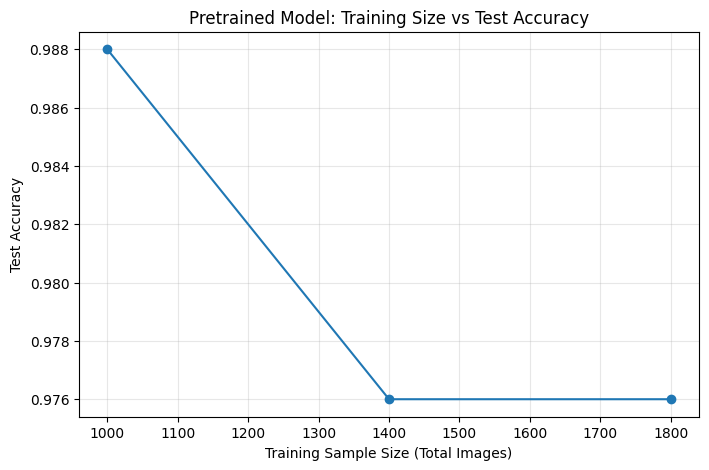

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(pretrained_df["train_total"], pretrained_df["test_accuracy"], marker="o")
plt.xlabel("Training Sample Size (Total Images)")
plt.ylabel("Test Accuracy")
plt.title("Pretrained Model: Training Size vs Test Accuracy")
plt.grid(True, alpha=0.3)
plt.show()

## 12. Final comparison table for report

In [18]:
summary_rows = [
    {
        "Approach": "Scratch",
        "Question": "Q1",
        "Training Total": 1000,
        "Validation Total": 500,
        "Test Total": 500,
        "Test Accuracy": q1_result["test_accuracy"]
    },
    {
        "Approach": "Scratch",
        "Question": "Q2",
        "Training Total": Q2_TRAIN_PER_CLASS * 2,
        "Validation Total": 500,
        "Test Total": 500,
        "Test Accuracy": q2_result["test_accuracy"]
    },
    {
        "Approach": "Scratch",
        "Question": "Q3 Best Size",
        "Training Total": int(best_scratch["train_total"]),
        "Validation Total": 500,
        "Test Total": 500,
        "Test Accuracy": float(best_scratch["test_accuracy"])
    },
    {
        "Approach": "Pretrained",
        "Question": "Q1 Repeat",
        "Training Total": 1000,
        "Validation Total": 500,
        "Test Total": 500,
        "Test Accuracy": pt_q1_result["test_accuracy"]
    },
    {
        "Approach": "Pretrained",
        "Question": "Q2/Q3 Best Size",
        "Training Total": int(best_pretrained["train_total"]),
        "Validation Total": 500,
        "Test Total": 500,
        "Test Accuracy": float(best_pretrained["test_accuracy"])
    },
]

summary_df = pd.DataFrame(summary_rows)
summary_df

,Approach,Question,Training Total,Validation Total,Test Total,Test Accuracy
0,Scratch,Q1,1000,500,500,0.504
1,Scratch,Q2,1400,500,500,0.606
2,Scratch,Q3 Best Size,1800,500,500,0.556
3,Pretrained,Q1 Repeat,1000,500,500,0.982
4,Pretrained,Q2/Q3 Best Size,1000,500,500,0.988


In [19]:
# Save the results for the written report
results_dir = Path("/content/drive/MyDrive/Colab Notebooks/assignment2_results")
results_dir.mkdir(parents=True, exist_ok=True)

scratch_df.to_csv(results_dir / "scratch_size_search_results.csv", index=False)
pretrained_df.to_csv(results_dir / "pretrained_size_search_results.csv", index=False)
summary_df.to_csv(results_dir / "assignment2_summary_table.csv", index=False)

print("Saved files to:", results_dir)
print(list(results_dir.glob("*")))

Saved files to: /content/drive/MyDrive/Colab Notebooks/assignment2_results
[PosixPath('/content/drive/MyDrive/Colab Notebooks/assignment2_results/scratch_size_search_results.csv'), PosixPath('/content/drive/MyDrive/Colab Notebooks/assignment2_results/pretrained_size_search_results.csv'), PosixPath('/content/drive/MyDrive/Colab Notebooks/assignment2_results/assignment2_summary_table.csv')]
